# Local meme enrichment

In questo notebook sarà mostrato come è possibile effettuare una analisi e arricchimento dei meme utilizzando solo modelli **che girano in locale**.  
Si andranno quindi a confrontare gli outputs di vari modelli locali allo stato dell'arte. I parametri di cui verrà tenuto conto saranno precisione, risorse utilizzate e velocità nella risposta.

Si andranno a confrontare due tipi di modelli:
- LLMs with vision: ovvero modelli in grado di processare una immagine e fornirne una descrizione più o meno dettagliata. Questo tipo di modello verrà utilizzato nella prima parte dell'analisi per fornire una preliminare analisi dell'immagine.
Questi modelli sono, in generale, resource intensive, per questo motivo si è scelto di valutare solo modelli non troppo pesanti. Si è tenuto conto di modelli quantizzati o modelli progettati per essere leggeri.

- Modelli di embedding: questi modelli produrranno un output utile per la ricerca semantica delle immagini. Effettueranno un mapping dei meme su uno spazio vettoriale, basandosi su feature testuali e/o sulla immagine del meme.


***
## Modelli che andremo a confrontare (LLMs with vision)
In particolare, per quanto riguarda gli LLMs si andranno a confrontare i seguenti modelli:

| **#** | **Nome (Link)**                                                     | **Parametri** | **RAM Approssimata** |
|-------|---------------------------------------------------------------------|---------------|----------------------|
| 1     | [LLAMA 3.2 Vision](https://ollama.com/library/llama3.2-vision)      | 11B           | ~10 GB               |
| 2     | [Moondream2](https://ollama.com/library/moondream)                  | ~1.8B         | ~4 GB               |
| 3     | [Llava-Phi3](https://ollama.com/library/llava-phi3)                 | 3.8B           | ~12 GB              |
| 4     | [Minicpm-v](https://ollama.com/library/minicpm-v)                   | ~1B           | ~6 GB               |



### Info aggiuntive
Questa è una lista di tutti i modelli vision disponibili su ollama: https://ollama.com/search?c=vision&o=newest  

Altri modelli degni di menzione potrebbero essere:
| **#** | **Nome (Link)**                                                     | **Parametri** | **RAM Approssimata** |
|-------|---------------------------------------------------------------------|---------------|----------------------|
| 1     | [Qwen2-VL-2B-Instruct-AWQ](https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct-AWQ) | 2B            | ~10 GB              |
| 2     | [SmolVLM](https://huggingface.co/blog/smolvlm)                      | ~500M         | ~4 GB               |  

Per ragioni pratiche non andremo a confrontare questi modelli, non disponibili su ollama, ma potrebbe essere interessante farlo in futuro.



Di recente, ollama, un popolare backend per le llm, ha introdotto la funzione [structured outputs](https://ollama.com/blog/structured-outputs) che ci tornerà utile per tutti i modelli che andremo ad utilizzare supportati da ollama.
Abbiamo definito un modello pydantic di meme nel file [utils/models.py](utils/models.py) . In questa maniera potremo utilizzare una LLM e farci restituire un output strutturato, validandone lo schema.



Per prima cosa [installiamo ollama](https://ollama.com/download).  

Successivamente scarichiamo [LLAMA 3.2 Vision](https://ollama.com/library/llama3.2-vision).  

Installiamo la libreria [ollama-python](https://github.com/ollama/ollama-python)

In [21]:
from pydantic import BaseModel
from typing import List, Optional, Literal


# Define the schema for image objects
class Object(BaseModel):
  name: str
  confidence: float
  attributes: str


class ImageDescription(BaseModel):
    summary: str
    objects: List[Object]
    scene: str
    colors: List[str]
    time_of_day: Literal['Morning', 'Afternoon', 'Evening', 'Night']
    setting: Literal['Indoor', 'Outdoor', 'Unknown']
    text_content: Optional[str] = None

default_prompt = "Analyze this image and return a detailed JSON description including objects, scene, colors and any text detected. If you cannot determine certain details, leave those fields empty."

In [ ]:
from pathlib import Path

path = Path("./tests/test.jpeg")

# Verify the file exists
if not path.exists():
    raise FileNotFoundError(f"Image not found at: {path}")

In [24]:
from ollama import chat
import time


def test_llm (model_name, image_path=path, output_pydantic_class=ImageDescription, prompt=default_prompt):
    print (f"Testing {model_name} with {image_path}")
    time_start = time.perf_counter()
    response = chat(
        model=model_name,
        format=output_pydantic_class.model_json_schema(),  # Pass in the schema for the response
        messages=[
            {
                "role": "user",
                "content": prompt,
                "images": [image_path],
            },
        ],
        options={
            "temperature": 0
        },  # Set temperature to 0 for more deterministic output
    )
    # Convert received content to the schema
    image_analysis = output_pydantic_class.model_validate_json(response.message.content)
    time_end = time.perf_counter()
    spent_time = time_end - time_start
    print(f"Took {spent_time:.3f} seconds testing {model_name}")
    return{
    "model": model_name,
    "output": image_analysis,
    #"output": image_analysis.model_dump_json(),
    "time": spent_time,
    }

In [22]:
prompt = "Analyze this meme image and return a detailed JSON description. If you cannot determine certain details, leave those fields empty."
outputs_and_times = dict()

In [36]:
from pydantic import ValidationError
from meme_analysis_pipeline.utils.models import Meme
llms_to_try = [
    "llama3.2-vision",
    "llava-phi3",
    "minicpm-v",
    "moondream"]
#llms_to_try= [llms_to_try[1]]
llms_to_try=llms_to_try[:-1]
for llm in llms_to_try:
    try:
        outputs_and_times[llm] = test_llm(llm, output_pydantic_class=Meme, prompt=prompt)
    except ValidationError as e:
        print(f"Validation error for model {llm}: {e}")

Testing llama3.2-vision with tests\test.jpeg
Took 598.446 seconds testing llama3.2-vision
Testing llava-phi3 with tests\test.jpeg
Took 40.337 seconds testing llava-phi3
Testing minicpm-v with tests\test.jpeg
Took 81.961 seconds testing minicpm-v


In [40]:
try:
    outputs_and_times["moondream"] = test_llm(
        "moondream", output_pydantic_class=Meme, prompt=prompt+ " Keep the output small and concise."
    )
except ValidationError as e:
    print(f"Validation error for model {llm}: {e}")

Testing moondream with tests\test.jpeg
Validation error for model minicpm-v: 1 validation error for Meme
  Invalid JSON: EOF while parsing a string at line 1 column 57561 [type=json_invalid, input_value='{"explainer": "A funny m...pusesai.co.uk", "reddit', input_type=str]
    For further information visit https://errors.pydantic.dev/2.10/v/json_invalid


: 

---
#### Llama 3.2 Vision

In [37]:
print(outputs_and_times["llama3.2-vision"]["output"])

visual_description="A cartoon duck with a knife in its beak is shown on the right side of the image. The text 'peace was never an option' is written to the left of the duck, and the top of the image has the words 'REDDITORS WHEN OP USES AI:'." image_text='REDDITORS WHEN OP USES AI:' explainer='meme' tags=['AI', 'Reddit']


---
#### Moondream

In [33]:
print(outputs_and_times["moondream"]["output"])

KeyError: 'moondream'

---
#### llava-phi3

In [38]:
print(outputs_and_times["llava-phi3"]["output"])

visual_description='A white duck with orange feet and a yellow beak. The duck is holding a knife in its beak.' image_text='peace was never an option' explainer='Redditors when of uses AI:' tags=['reddit', 'AI', 'meme']


---

#### minicpm-v

In [39]:
print(outputs_and_times["minicpm-v"]["output"])

visual_description='A cartoon duck is shown holding a knife in its beak, standing on what appears to be wooden planks. The background suggests a simplistic or rudimentary digital environment.' image_text="The text on the image reads 'REDDITORS WHEN OP USES AI: peace was never an option'." explainer='This image is a meme that uses humor to depict the hypothetical scenario where Reddit users employ AI for their activities.' tags=['meme', 'humor', 'Reddit', 'AI']


---

In [34]:
print (outputs_and_times)

{}


In [ ]:
%store outputs_and_times

---

### Conclusioni
Ho associato ad ogni output un punteggio di qualità, basato sulla precisione e sulla completezza dell'output. Questo punteggio è soggettivo.
Inoltre ho misurato, per ogni modello, il tempo di risposta per ogni immagine. Questo tempo è stato misurato considerando un hardware di fascia medio-bassa (i3 8100, 32 GB RAM, 1050 Ti 4GB).

| **Numero** | **Nome Modello**   | **Qualità Output** | **Tempo di Esecuzione / Immagine** |
|------------|--------------------|--------------------|------------------------------------|
| 1          | LLAMA 3.2 Vision   |Eccellente          | ~450 secondi                       |
| 2          | Moondream 2        |Bassa               | ~10 secondi                        |
| 3          | LLAVA-Phi 3        |Ottima              | ~28 secondi                        |
| 4          | MiniCPM-V          |Ottima              | ~75 secondi                        |

In generale, il modello Moondream 2 è il più veloce, ma anche il meno preciso. LLAMA 3.2 Vision è il più preciso, ma anche il più lento. LLAVA-Phi 3 e MiniCPM-V sono un buon compromesso tra velocità e precisione. Poichè il tempo impiegato da LLAVA-Phi 3 è meno della metà del tempo impiegato da MiniCPM-V, si decide di procedere utilizzando LLAVA-Phi 3.

***



### Analizziamo un meme con LLAVA-Phi 3

## Modelli di embedding
Per quanto riguarda i modelli di embedding, bisogna distinguere tra modelli che lavorano solo sul testo e modelli che lavorano su testo e immagine.
Per quanto riguarda quest'ultimi si è scelto di usare clip, un modello sviluppato da OpenAI che lavora su testo e immagine.
Faremo uso della libreria [OpenClip](https://github.com/mlfoundations/open_clip/tree/main).  


#### Mostriamo i modelli pretrainati disponibili

Utilizzeremo il modello "ViT-B-32", pretrainato su "laion2b_s34b_b79k"

#### Facciamo un test
Per provare il modello andremo a vedere se il modello è in grado di classificare correttamente la nostra immagine di test.  
L'immagine di test è la seguente:

![test_image](tests/test.jpeg)  

Confronteremo gli embeddings dell'immagine con gli embeddings delle seguenti stringhe:
- "a duck"
- "a dog"
- "a chair"
- "a meme"
- "a meme about a duck"
- "a pencilcase"

Poi andremo a plottare le distanze tra l'immagine e le stringhe.


In [25]:
import torch
from PIL import Image
import open_clip

model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="laion2b_s34b_b79k"
)
model.eval()  # model in train mode by default, impacts some models with BatchNorm or stochastic depth active
tokenizer = open_clip.get_tokenizer("ViT-B-32")

image = preprocess(Image.open("./tests/test.jpeg")).unsqueeze(0)
classes= ["a duck", "a dog", "a chair", "a meme", "a meme about a duck", "a pencilcase"]
text = tokenizer(classes)

with torch.no_grad(), torch.cuda.amp.autocast():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)

print("Label probs:", text_probs)  

Label probs: tensor([[5.1824e-04, 3.9235e-08, 1.0491e-08, 2.3647e-03, 9.9712e-01, 5.5169e-08]])


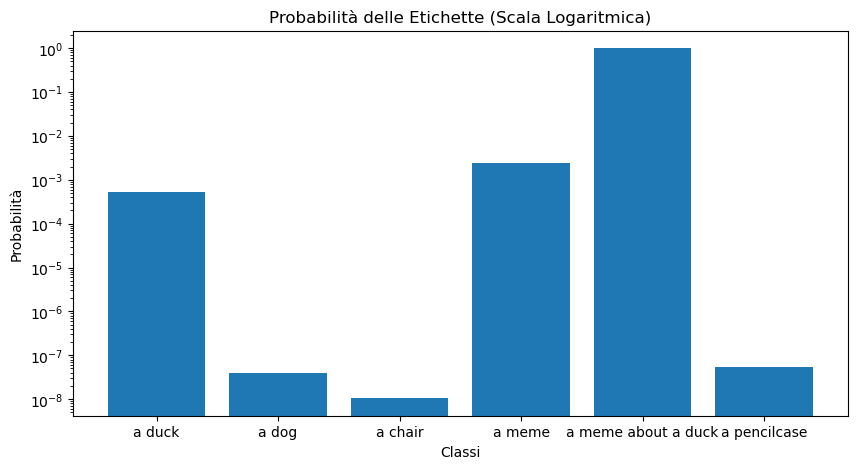

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Convertiamo text_probs in un array numpy
text_probs_np = text_probs.detach().numpy().flatten()


# Creiamo un plot
plt.figure(figsize=(10, 5))
plt.bar(classes, text_probs_np)
plt.yscale("log")
plt.xlabel("Classi")
plt.ylabel("Probabilità")
plt.title("Probabilità delle Etichette (Scala Logaritmica)")
plt.show()

Possiamo notare che l'immagine è più vicina a "a meme about a duck" rispetto a "a duck" e "a dog". Questo è un buon segno, poichè l'immagine è effettivamente un meme di un'anatra.
Il risultato è ancora migliore se consideriamo che stiamo utilizzando una scala logaritmica per effettuare il plot. Se utilizziamo una scala lineare, possiamo notare che la distanza tra l'immagine e "a meme about a duck" è di diversi ordini di grandezza più piccola rispetto alle altre distanze, abbiamo quindi un risultato decisamente ottimo.

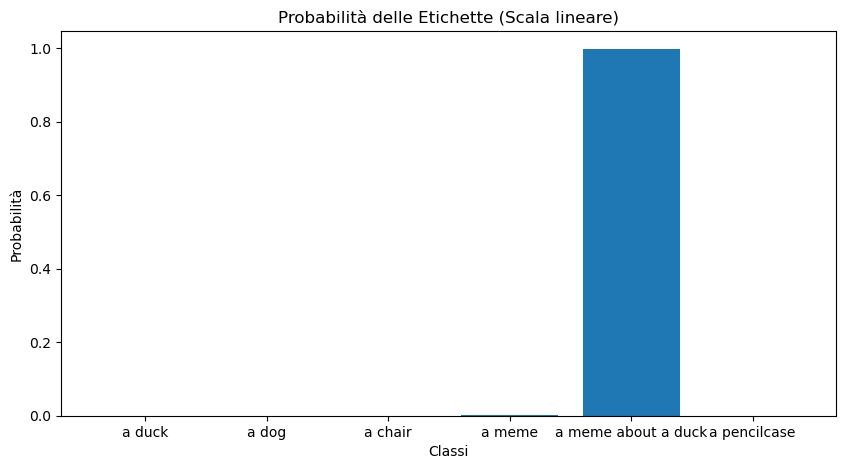

: 

In [29]:
plt.figure(figsize=(10, 5))
plt.bar(classes, text_probs_np)
plt.xlabel("Classi")
plt.ylabel("Probabilità")
plt.title("Probabilità delle Etichette (Scala lineare)")
plt.show()